# Tutorial: CO<sub>2</sub> binding to the COF-999 framework

In this tutorial we will learn about how to calculate approximate transition state energies of the CO<sub>2</sub> binding process to the COF-999 organic framework in the absence and in the presence of a water molecule. We will learn, that the transition state energy is lowered in the presence of water, irrespective of the reaction mechanism, thus facilitating the binding process. The data that form the basis for this investigation are derived from [this article][article_link].

We have already prepared and included some data for you with this tutorial. If you are interested in how these molecular structures were obtained, unfold the following section. This will shed some light on the quality of results to be expected from this tutorial any why it should be taken with a grain of salt. You can also skip this and go straight to the coding part.

[article_link]: https://www.nature.com/articles/s41586-024-08080-x

<a id="data_construction"></a>
## Construction of the data for the tutorial

**This section provides some background on how the structures for the tutorial were obtained and may be skipped.**

The data for the tutorial come from the [supplementary information](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-024-08080-x/MediaObjects/41586_2024_8080_MOESM1_ESM.pdf) of the above mentioned [article](https://www.nature.com/articles/s41586-024-08080-x). Since the coordinates were given as crystallographic data, they were transformed into euclidean space and unfolded in three dimensions prior to trimming the model to a single ring. The three dimensional unfolding was necessary to make sure that all atoms from neighboring unit cells were considered before trimming the model to a single ring structure.

After trimming, we used [xTB's constrained optimization module](https://xtb-docs.readthedocs.io/en/latest/optimization.html) to optimize the structure in vacuum. Constraints were put on the pairwise distances between the corner atoms of the 6-ring such that the distances between neighboring and diagonal atom pairs would be preserved. Additional constraints were added to keep the opposite atoms on the faces of the 6 ring at a constant distance at which the \"arms\", that reach into the ring, are attached. These choices were taken, because the ring is bound into an organic framework which holds certain corner positions in place - if optimized without these constraints, the ring would deform unnaturally. In the following we always use the GFN2-xTB energy function and the same constraints, unless noted otherwise.

The placement of the CO<sub>2</sub> molecule was achieved by simply putting it in the proximity of the center axis through the ring followed by a constrained structure optimization. It turns out that the CO<sub>2</sub> molecule \"drops\" into the ring and becomes bound non-covalently. Here are two videos of the optimization process that show the gradient driven placement of the CO<sub>2</sub> molecule:

<video width="320" height="240" controls>
  <source src="data/video1_1280.mp4" type="video/mp4">
</video>
<video width="320" height="240" controls>
  <source src="data/video2_1280.mp4" type="video/mp4">
</video>

To place the water molecule, we took an educated guess and put it in the vicinity of the CO<sub>2</sub> molecule followed by another round of constrained optimizations. The optimized structure with and without H<sub>2</sub>O constitute the starting points for the reaction calculations. In order to construct the end points, atoms were moved manually using [Avogadro](https://avogadro.cc/), placing them close to a chemically intuitive structure after carbamate formation, followed by another round of constrained optimization with xTB. The produced files then constituted the final structures, i.e. the product of the reaction.

Since the reaction may be explained by two different mechanisms in the presence of water, some hydrogen atoms needed to be aligned to accommodate for the difference in reaction mechanism. To reduce the model size we again used Avogadro and cut the chemical structure at single bonds close to the binding site. The corresponding atoms were capped with hydrogens at the position of the original neighbor atom followed by a re-optimization of only the hydrogen positions. This model is the one we have used in the showcase and will be the one we use here, albeit with a minimal basis set.

<img src="data/example_large.png" alt="large model" width="600"/>
<img src="data/example_small.png" alt="small model" width="600"/>

The configurations provided here serve merely as possible examples of transition states, and illustrate how similar calculations could be done if a more accurate description is available.

<a id="overview"></a>
## Overview
We are interested in the calculation of three transition state energies derived from modelling the binding of CO<sub>2</sub> to the COF-999 framework. When CO<sub>2</sub> binds to the COF-999 framework it does so preferably at primary amines at the tips of long tentacle like structures reaching in the lumen of the ring under [carbamate](https://en.wikipedia.org/wiki/Carbamate) formation. The three transition states we will be looking at may be described as

- The transition state of the direct carbamate formation from CO<sub>2</sub> bound to COF-999 in the absence of water.  The data for this transition state can be found in `data/small_model/co2_direct/ts.xyz`.
- The transition state of the direct carbamate formation from CO<sub>2</sub> bound to COF-999 in the presence of water.  The data for this transition state can be found in `data/small_model/co2_and_h2o_direct/ts.xyz`.
- The transition state of in the carbamate formation from CO<sub>2</sub> bound to COF-999 mediated by a proton exchange in the presence of water. The data for this transition state can be found in `data/small_model/co2_and_h2o_proton/ts.xyz`.

Now let us start by importing the main modules and setting a folder where we will store the calculation output. Also we will set Qrunch to print the most essential logging information, which is useful to track progress in longer-lasting calculations.

In [1]:
import qrunch as qc
from pathlib import Path

output_path = Path("output")
output_path.mkdir(exist_ok=True, parents=True)
qc.setup_logger()

<a id="experiment_setup"></a>
## Setting up the experiment

The purpose of this exercise is to compare the transition state energies for the small model as introduced in the [Construction of the data for the tutorial](#data_construction) section. We start by loading the structures from the input path. One additional bit of knowledge that enters in the molecular configuration is the definition of the _embedded atoms_, i.e. the atoms that will be treated \"on the quantum computer\". We are using a theory called [projection-based wavefunction-in-DFT emebdding](https://qrunch.docs.kvantify.net/docs/explanations/projective_embedding.html) (based on [this publication](https://pubs.acs.org/doi/10.1021/acs.accounts.8b00672)) and the wave function part is run on the quantum computer while experiencing an effective potential given by a DFT electron density.

Note that the enumeration of embedded is 0-based, as is standard for python and care must be taken when checking the identity of the atoms. Also, the direct transition from CO<sub>2</sub> to carbamate has the same embedded atoms in the presence and absence of water. Thus, the wave function calculation in the presence of water only feels the water molecule's effective potential. However, in the reaction via the proton exchange mechanism, additional atoms need to be considered, as shown in the code cell.

In [2]:
input_path = Path("data/small_model")
path_co2_direct = input_path / "co2_direct" / "ts.xyz"
path_co2_and_h2o_direct = input_path / "co2_and_h2o_direct" / "ts.xyz"
path_co2_and_h2o_proton = input_path / "co2_and_h2o_proton" / "ts.xyz"
embedded = [3, 9, 34, 35, 36]
ts_co2_direct = qc.build_molecular_configuration(path_co2_direct, basis_set="sto3g", embedded_atoms=embedded)
ts_co2_and_h2o_direct = qc.build_molecular_configuration(path_co2_and_h2o_direct, basis_set="sto3g", embedded_atoms=embedded)
ts_co2_and_h2o_proton = qc.build_molecular_configuration(path_co2_and_h2o_proton, basis_set="sto3g", embedded_atoms=embedded + [31, 37, 39])

transition_states = [ ts_co2_direct, ts_co2_and_h2o_direct, ts_co2_and_h2o_proton ]

Here we have put all transition states into one common list, which makes data handling a bit more convenient at a later stage. 

## Creating the problem with the problem builder
In this section we will use the [fluent builder pattern](https://qrunch.docs.kvantify.net/docs/explanations/builder_pattern.html) to construct a `problem_builder` - which will later take the molecular configuration as an input. The problem builder itself may be configured in different ways, guided by the fluent builder pattern and code completion, which we will do now. We start by requesting a `creator` for a problem builder, specifying that we want to calculate a `ground_state` and we will do so by using the `projective_embedding` theory:

In [3]:
problem_builder_creator = qc.problem_builder_creator().ground_state().projective_embedding()

The reasoning when using the `problem_builder_creator` is of narrowing down our choices from more general to more specific: each function executed on the `problem_builder_creator` returns a more specialized or differently configured instance of it. We will focus on guiding you through the different steps of the specification and configuration. In a typical script, one would just chain the specialization functions until the `.create()` method is called, which would return the `problem_builder` directly.

### Setting the DFT functional
Since projective embedding comes naturally along with some DFT calculation, we may also select a density functional. This we can define using the `DFTCalculatorOptions` available from `qc.options`. For the purposes of this tutorial, we will use the B3LYP functional, because it is fast, but more accurate (and slower) functionals are in general recommended, e.g. `wb97m-v`.

In [4]:
dft_options = qc.options.DftCalculatorOptions(functional="b3lyp")
problem_builder_creator = problem_builder_creator.choose_full_system_solver().dft(dft_options)

### Define the active space

We will decide how many qubits our calculation should use and that is related to the size of the active space. Since we are using the [Jordan-Wigner transformation](https://qrunch.docs.kvantify.net/docs/references/_autosummary/qrunch.quantum.operators.mappers.jordan_wigner.mapper.html#qrunch.quantum.operators.mappers.jordan_wigner.mapper.JordanWignerMapper) to map orbitals to qubits, we need one qubit per spin orbital (or two qubits per spatial orbital). Thus, by choosing the size of the active space, we will define how many qubits our quantum algorithm will require. 

The active space specifications are added to our reaction builder as a `problem_modifier`. Here, we will consider 6 active spatial orbitals and 6 active electrons, which requires 12 qubits. This active space size is too small for accurate calculations, but enough for illustration purposes. 

Early on, we defined the spin difference as 0 which allows us to run a "restricted" calculation. This ensures that the number of alpha and beta electrons assigned to the embedded atoms is the same and the embedded space spin difference will also be 0. The number of beta electrons will be determined automatically by the embedded space spin difference and the specified number of alpha electrons. Thus we can construct the desired (6,6) active space by selecting the numbers as given in the following code cell.

In [5]:
problem_builder_creator = (problem_builder_creator.add_problem_modifier()
        .active_space(
            number_of_active_spatial_orbitals=6,
            number_of_active_alpha_electrons=3,
        )
)

Note - in an embedded unrestricted calculation (and to some degree in am embedded restricted open shell calculation) the above rationale does not necessarily hold and the number of beta electons may in general be different from the specified number of alpha electrons and one does not have explicit control over the number of electrons in the active space.

### Define a checkpoint directory
If desired, checkpoint files for the calculations are constructed on-the-fly - and upon re-execution of the same (or similar) scripts the data will be loaded again. This is very useful, e.g. if you want to change the size of the active space, there is no need to re-run the DFT calculation for the whole system from scratch, or if you want to move your calculation from a simulator to hardware it is possible to even re-use the active space construction. The file-loading is not of concern here as it is completely automated - it is only meant to illustrate how storing intermediate files may be helpful. We will now use the `output` folder defined [above](#overview) as our checkpoint folder. As there may be many files, we will store everything in a subdirectory called `persister_files`.

In [6]:
persister_files = output_path / "persister_data"
persister_files.mkdir(exist_ok=True, parents=True)
problem_builder_creator = problem_builder_creator.choose_data_persister_manager().file_persister(persister_files)

### Optional step: Adding the cube generator

In order to be able to visualize the electron densities later, we will have to generate the files with the volume data. This can be done by defining a cube generator and adding it to the `problem_builder_creator`. We configure the cube file generator such that it will put all the data into a subfolder in our output directory, called `cube`.

In [7]:
cube_files = output_path / "cube"
cube_files.mkdir(exist_ok=True, parents=True)
cube_generator = qc.cube_file_generator_creator().projective_embedding().with_base_file_path(cube_files / "ts_for_reaction").with_embedding_components(["total"]).with_environment_components(["total"]).with_overwriting_policy("rename").create()
problem_builder_creator = problem_builder_creator.with_cube_generator(cube_generator)

### Finalizing the creator flow and building the problem

To finalize the flow pattern, we simply call the `.create()` method which returns a `problem_builder`. We may have arrived there similarly by running

```
problem_builder = (
    qc.problem_builder_creator()
    .ground_state()
    .projective_embedding()
    .choose_full_system_solver()
    .dft(dft_options)
    .add_problem_modifier()
    .active_space(
        number_of_active_spatial_orbitals=6,
        number_of_active_alpha_electrons=3,
    )
    .choose_data_persister_manager()
    .file_persister(output_path / "persister_files")
    .create()
)
```
instead of splitting it up into individual steps. With the problem builder in our hands we can finally create the problem that we want to solve. Since, however, we have three problems that we need to create and solve, we will have to defer building the problem to a later point.

In [8]:
problem_builder = problem_builder_creator.create()
# problem = problem_builder.build_restricted(molecular_configuration)

<a id="quantum_algorithm_definition"></a>
## Defining the quantum algorithm

Up until now, we have just defined the classical preprocessing of the data that defines the Hamiltonian for which we wish to find an (approximate) ground state solution using a quantum algorithm. Now we need to decide which quantum algorithm to use, where to run the calculation and with which specifications. We will choose a non-trivial construction of the algorithm to be able to control where and how we want to run each part. Note that the default setting is to use a noise-free state vector simulator - but we are also able to specify some actual hardware to run our experiments on.

Here, we resort to using the `memory_restricted` option both for the estimator and the sampler. This simulator is available with the Pro license of the Qrunch, and is a good option for running quick simulations of the adaptive algorithms. It allows us to truncate the simulated state with a number of amplitudes or, as we do here, with a maximum amount of memory.

When defining the quantum algorithm, we will again make use of the [fluent builder pattern](https://qrunch.docs.kvantify.net/docs/explanations/builder_pattern.html). Now that you are used to how it works, we may specify the whole process in one call and describe the parts afterwards. For details on choices such as `with_shots`, `with_heuristic_gradient` and `choose_minimizer`, check out our [documentation](https://qrunch.docs.kvantify.net/index.html) page, or one of our other tutorials.

In [9]:
# Define the sampler for the quatum algorithm and where and how it is used
shots = 1000
sampler = qc.sampler_creator().memory_restricted().with_max_memory(1024**2).create()
gate_selector = qc.gate_selector_creator().fast().with_shots(shots).with_sampler(sampler).with_heuristic_gradient().create()

# Define the estimator - it is recommended that we always use some kind of noise-free simulator for the estimator
estimator = qc.estimator_creator().memory_restricted().with_max_memory(1024**2).create()

Getting the calculator is then straight forward

In [10]:
calculator = (
    qc.calculator_creator()
    .vqe()
    .iterative()
    .standard()
    .with_estimator(estimator)
    .with_gate_selector(gate_selector)
    .create()
)

Now we are in a position to run the calculations and get the result data for all three configurations (this takes about 5 minutes the first time it is run - and about 4 seconds, due to restarting from the stored intermediate files, afterwards). We will generate a list and append the results of calculations to the it.

In [11]:
energies = []
for molecular_configuration in transition_states:
    problem = problem_builder.build_restricted(molecular_configuration)
    result = calculator.calculate(problem)
    energies.append(result.total_energy.value)
print("Energies:", energies)

2025-10-27 13:10:59 [ESSENTIAL] (kvantify.qrunch): Run Adaptive VQE algorithm with 12 qubits:
2025-10-27 13:10:59 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 1 / 10: -8.785351935348725
2025-10-27 13:10:59 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 2 / 10: -8.798929596100013
2025-10-27 13:10:59 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 3 / 10: -8.802662928529385
2025-10-27 13:10:59 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 4 / 10: -8.805140037564422
2025-10-27 13:10:59 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 5 / 10: -8.807681035105816
2025-10-27 13:10:59 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 6 / 10: -8.812821121232453
2025-10-27 13:10:59 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 7 / 10: -8.817511541113692
2025-10-27 13:10:59 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 8 / 10: -8.818601962014716
2025-10-27 13:10:59 [ESSENTIAL] (kvantify.qrunch): Adaptive VQE iteration: 9 / 10: -8.8197

Energies: [-827.7581360992533, -903.1258443724234, -902.8017514281582]


## Now you

The tasks below are meant as an inspiration for how to change the notebook in different ways and they are largely orthogonal to each other.

- Note that the algorithm did not converge within the predefined number of iterations. Try and go back to the vqe definition and use the `.with_options()` function together with the option definition `kq.options.AdaptiveVqeOptions` to increase the number of iterations until the algorithm successfully converges.
- For the optional data visualization below the starting point energies are required. Try and extend the code to calculate the corresponding starting point energies using the supplied `start.xyz` files.
- Up until now, all calculations have been run on a perfect (noise-free) simulator (only shot-noise considered). Find out how the results change by running on a noisy simulator. To do this, replace the `sampler` by a different one, e.g. the Amazon Braket local simulator available via `local_braket()`. To make sure that you are using a noisy simulation, you also need to specify some noisy device data using the `DeviceData` structure.
- Run the sampler on actual hardware, e.g. via IQM Resonance or Amazon Braket - the estimator should remain the same simulator for all calculations as the noise on current hardware is typical way too large to be able to estimate energies accurately.
- Increase active spaces and start playing with the input - e.g. derive your own models from `data/large_model`, find your own transition states, reaction mechanisms etc.
- Use your own molecule data as input data

# Data visualization

This part requires optional dependencies in the environment. These can be installed with

```
pip install matplotlib
```

In [12]:
import matplotlib.pyplot as plt
import numpy as np


One of the most interesting diagnostics on adaptive VQE runs is to display their convergence. We will use the last result currently stored in the `result` variable for this purpose. You may wish to collect the data for more than just the last point and compare the convergence for the different transition states and or starting states. This may be illuminating with respect to how difficult it is to solve the electronic structure and the noise level in the simulation. Slower convergence may be an indicator for more difficult electronic structures (at otherwise comparable noise levels) or higher noise levels (for comparable electronic structures).

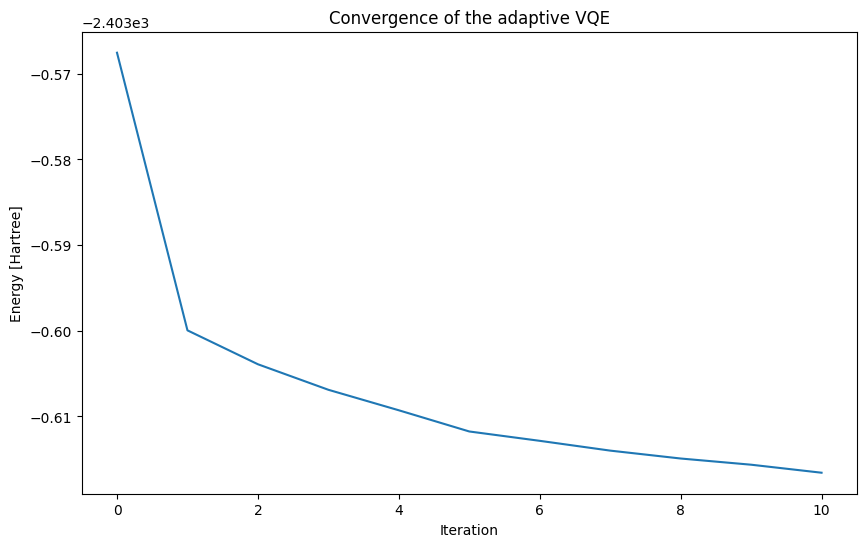

In [13]:
conv_fig, conv_ax = plt.subplots(ncols=1, nrows=1, figsize=(10, 6))
conv_data = [v.value for v in result.electronic_energy_per_macro_iteration_with_initial_energy]
conv_ax.plot(conv_data)
conv_ax.set_title("Convergence of the adaptive VQE")
conv_ax.set_xlabel("Iteration")
conv_ax.set_ylabel("Energy [Hartree]")
plt.show()

## Visualizing the reaction energies 
The main question that we tried to answer was as to whether the presence of water has an effect on the CO<sub>2</sub> binding kinetics. To elucidate this, we focused on the transition state energies of three different reactions, i.e. the direct conversion to carbamate in the absence and presence of water and a reaction that was facilitated by a proton exchange mechanism, which becomes only feasible in the presence of water. 

To answer this question, we will now visualize the calculated transition state energies. However, these energies are not directly, comparable because the additional water lowers the total energy of the system dramatically and also it is more interesting to see the transition state energies in the context of a whole reaction.

Starting with the latter, the GFN2-xTB energies are supplied for the whole reaction, see the following code panel, where the data is included directly. Note that the curves are shifted such that the starting point is at 0.0. 

In [14]:
# Data from xTB calculations for comparison
co2_direct_path_energies = np.array([-61.17641763, -61.16876945, -61.15579435, -61.14453586, -61.1170315, -61.10341216, -61.04231932, -61.16340239, -61.2070893])
co2_and_h2o_direct_path_energies = np.array([-65.26757781, -65.26056757, -65.24661069, -65.22210019, -65.17371786, -65.15468766, -65.21433863, -65.26021185, -65.28870702])
co2_and_h2o_proton_path_energies = np.array([-65.26757781, -65.25975392, -65.23802172, -65.21709347, -65.16618551, -65.1690354, -65.20385045, -65.24709548, -65.28817211])

xtb_path_energies = [co2_direct_path_energies, co2_and_h2o_direct_path_energies, co2_and_h2o_proton_path_energies]

# Shift energies such that the starting point of the reaction is at 0
xtb_path_energies = [xtb - xtb[0] for xtb in xtb_path_energies]

In order to plot comparable numbers we need to calculate the starting point energies in the exact same way as the transition state energies, i.e. we can reuse the calculator and vqe setup from before. To implement this is left as an exercise to the reader (see above) - here we just supply the corresponding energies.

In [15]:
starting_point_energies = np.array([-827.9356807952458, -903.2733953716167, -902.9069625821428])

Once the starting point energies have been determined we may easily plot the so determined transition state energies and compare them with the GFN2-xTB results. Here, the data show the same trend for the embedding calculation, i.e. the reaction with the highest transition state energy is the direct conversion in the absence of water, and the one with the lowest transition state energy is the proton transfer facilitated reaction in the presence of water.

The results here are consistent with the fact that CO<sub>2</sub> binding to the organic framework is more efficient in the presence of water

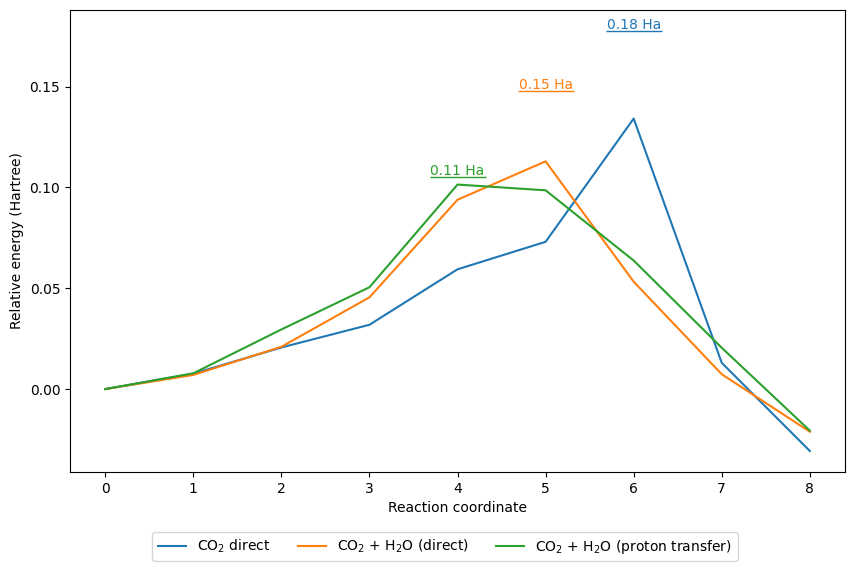

In [16]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(10, 6))
labels = ["CO$_2$ direct", "CO$_2$ + H$_2$O (direct)", "CO$_2$ + H$_2$O (proton transfer)"]
for xtb_path_energy, calculated_ts_energy, label in zip(xtb_path_energies, energies - starting_point_energies, labels):
    p = ax.plot(range(len(xtb_path_energy)), xtb_path_energy, label=label)
    ts_pos = np.argmax(xtb_path_energy)
    ax.plot(ts_pos, calculated_ts_energy, marker='_', color=p[0].get_color(), markersize=40)
    ax.annotate(f"{calculated_ts_energy:.2f} Ha", (ts_pos, calculated_ts_energy+0.001), ha='center', color=p[0].get_color())

fig.legend(loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05))
ax.set_xlabel("Reaction coordinate")
ax.set_ylabel("Relative energy (Hartree)")
plt.show()